In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from scipy.ndimage import shift

try:
    
    train_data = pd.read_csv("mnist_train.csv")
    y_train = train_data['label'].values
    X_train = train_data.drop('label', axis=1).values
    X_train = X_train / 255.0 

    test_data = pd.read_csv("mnist_test.csv")
    y_test = test_data['label'].values
    X_test = test_data.drop('label', axis=1).values
    X_test = X_test / 255.0 

except: 
    print("CSV file not fouund.")

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (60000, 784)
Test Data Shape: (10000, 784)


Creating Shifted Test Set...


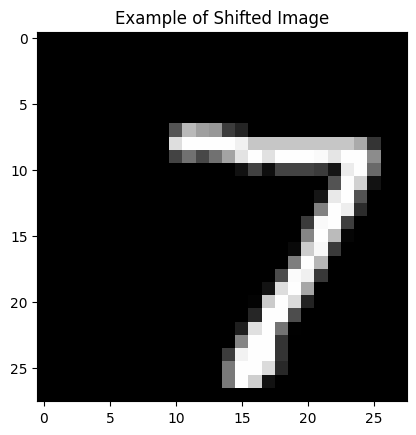

In [ ]:
def shift_images(data, shift_amount=4):
    images = data.reshape(-1, 28, 28)
    shifted_images = np.zeros_like(images)
    
    for i in range(len(images)):
        shifted_images[i] = shift(images[i], [0, shift_amount], mode='constant', cval=0)
        
    return shifted_images

print("Creating Shifted Test Set...")

X_test_shifted_img = shift_images(X_test, shift_amount=4)


X_test_shifted_flat = X_test_shifted_img.reshape(-1, 784)


X_test_shifted_cnn = X_test_shifted_img.reshape(-1, 28, 28, 1)

plt.imshow(X_test_shifted_img[0], cmap='gray')
plt.title("Example of Shifted Image")
plt.show()

Creating the FCNN MOdel and traing the Model

In [ ]:
model_a = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_a.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_a = model_a.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

Training FCNN
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9177 - loss: 0.2923 - val_accuracy: 0.9658 - val_loss: 0.1234
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9647 - loss: 0.1191 - val_accuracy: 0.9727 - val_loss: 0.0926
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9748 - loss: 0.0826 - val_accuracy: 0.9733 - val_loss: 0.0866
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9808 - loss: 0.0628 - val_accuracy: 0.9758 - val_loss: 0.0885
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9848 - loss: 0.0491 - val_accuracy: 0.9762 - val_loss: 0.0813


Creating the CNN MOdel

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

inputs = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)

x = layers.GlobalAveragePooling2D()(x)


x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model_b = models.Model(inputs=inputs, outputs=outputs)

model_b.summary()

model_b.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Training CNN")
model_b.fit(X_train_cnn, y_train, epochs=5, batch_size=64, verbose=1)

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,578 (396.79 KB)

 Trainable params: 101,578 (396.79 KB)

 Non-trainable params: 0 (0.00 B)

Training CNN
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8936 - loss: 0.3327
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9693 - loss: 0.1000
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9786 - loss: 0.0691
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9840 - loss: 0.0532
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9870 - loss: 0.0420


Evaluate and compare the FCNN and CNN models

In [ ]:

acc_a_norm = model_a.evaluate(X_test, y_test, verbose=0)[1]
acc_a_shift = model_a.evaluate(X_test_shifted_flat, y_test, verbose=0)[1]
drop_a = acc_a_norm - acc_a_shift

print(f"Model A (FCNN) Normal Accuracy:  {acc_a_norm:.2%}")
print(f"Model A (FCNN) Shifted Accuracy: {acc_a_shift:.2%}")
print(f"Accuracy Drop: {drop_a:.2%}")

print("-" * 40)


acc_b_norm = model_b.evaluate(X_test_cnn, y_test, verbose=0)[1]
acc_b_shift = model_b.evaluate(X_test_shifted_cnn, y_test, verbose=0)[1]
drop_b = acc_b_norm - acc_b_shift

print(f"Model B (CNN)  Normal Accuracy:  {acc_b_norm:.2%}")
print(f"Model B (CNN)  Shifted Accuracy: {acc_b_shift:.2%}")
print(f"Accuracy Drop: {drop_b:.2%}")

Model A (FCNN) Normal Accuracy:  97.48%
Model A (FCNN) Shifted Accuracy: 35.78%
Accuracy Drop: 61.70%
----------------------------------------
Model B (CNN)  Normal Accuracy:  98.42%
Model B (CNN)  Shifted Accuracy: 88.85%
Accuracy Drop: 9.57%
